# Interactions, Slopes, and Fairness Analysis

In this class, **fairness analysis** means checking whether a model behaves differently for different groups. We might compare predicted probabilities, false positive rates, false negative rates, precision, calibration, or who gets flagged by the model.

Common groups in fairness analysis include race, ethnicity, gender, age, disability status, language, income, neighborhood, immigration status, and other categories connected to unequal treatment or unequal consequences.

This notebook uses generic groups:

- `group = A`
- `group = B`

The main idea is simple:

> A model with `group` but no interaction can give groups different baseline predictions. A model with `group × prior_arrests` can also let prior arrests matter differently by group.

## Why Use OLS Here?

The issue is not specific to OLS. Some version of it shows up in all of the prediction models we have discussed: logistic regression, decision trees, random forests, and gradient boosting.

The fairness question is whether a predictor like `prior_arrests` carries the same information for each group. If it does not, then a model that forces one common relationship may make systematically different errors across groups. Those errors can show up in calibration, false positive rates, false negative rates, or who gets flagged by the model.

OLS gives the cleanest picture of this because it draws lines. Each line has two parts:

- the **intercept**: the baseline prediction when `prior_arrests = 0`
- the **slope**: how much the prediction changes as `prior_arrests` increases

Even though the outcome here is binary, we can use OLS as a **linear probability model**. The fitted value is interpreted as a predicted probability.

The intercept/slope distinction matters because adding `group` without an interaction changes the intercept: groups can start at different baseline levels, but the lines stay parallel.

Adding `group × prior_arrests` changes the slope: the model can now say that prior arrests matter more or less depending on the group.

Substantively, this means the model is allowed to treat the same predictor as carrying different information for different groups. For example, if one group is more heavily policed, then prior arrests may reflect not only prior offending, but also greater surveillance and enforcement. In that setting, one additional prior arrest may not have the same predictive meaning for every group.

A model without an interaction says:

> One additional prior arrest changes predicted future-arrest probability by the same amount for every group.

A model with an interaction says:

> One additional prior arrest may be associated with a larger or smaller change in predicted future-arrest probability depending on the group.

That is the intuition we want before moving to more complex models, where the same idea exists but is harder to see directly.

## 1. Generate a Binary Outcome Dataset

Each row is one person. The outcome `future_arrest` is binary:

- `0` = not arrested in the future
- `1` = arrested in the future

The data are generated so that future arrest becomes more common as prior arrests increase. That relationship is stronger for Group B than for Group A.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

sns.set_theme(style='whitegrid')

rows = []

cell_specs = [
    ('A', 0, 0.10),
    ('A', 1, 0.20),
    ('A', 2, 0.30),
    ('A', 3, 0.40),
    ('B', 0, 0.20),
    ('B', 1, 0.45),
    ('B', 2, 0.70),
    ('B', 3, 0.95),
]

for group, prior_arrests, arrest_rate in cell_specs:
    n_people = 20
    n_arrested = int(round(arrest_rate * n_people))
    n_not_arrested = n_people - n_arrested

    for i in range(n_arrested):
        rows.append({
            'group': group,
            'group_b': 1 if group == 'B' else 0,
            'prior_arrests': prior_arrests,
            'future_arrest': 1
        })

    for i in range(n_not_arrested):
        rows.append({
            'group': group,
            'group_b': 1 if group == 'B' else 0,
            'prior_arrests': prior_arrests,
            'future_arrest': 0
        })

example = pd.DataFrame(rows)

example.head()

,group,group_b,prior_arrests,future_arrest
0,A,0,0,1
1,A,0,0,1
2,A,0,0,0
3,A,0,0,0
4,A,0,0,0


To see the pattern we built into the individual-level data, compute the arrest rate within each `group` and `prior_arrests` cell.

In [2]:
cell_rates = example.groupby(['group', 'prior_arrests'], as_index=False)['future_arrest'].mean()
cell_rates

,group,prior_arrests,future_arrest
0,A,0,0.10
1,A,1,0.20
2,A,2,0.30
3,A,3,0.40
4,B,0,0.20
5,B,1,0.45
6,B,2,0.70
7,B,3,0.95


We will show these cell-level arrest rates as points in the plots. The OLS models are fit to the individual 0/1 rows, not to this summary table.

## 2. Model Without Group

First, fit a model that only uses prior arrests:

$$
\widehat{future\_arrest} = \hat{b}_0 + \hat{b}_1 prior\_arrests
$$

This model does not know which group a person belongs to. It has to use one line for everyone.

In [3]:
model_no_group = LinearRegression()
model_no_group.fit(example[['prior_arrests']], example['future_arrest'])

no_group_coefficients = pd.DataFrame({
    'term': ['intercept', 'prior_arrests'],
    'coefficient': [model_no_group.intercept_, model_no_group.coef_[0]]
})

no_group_coefficients

LinearRegression()

,term,coefficient
0,intercept,0.150
1,prior_arrests,0.175


The coefficients come from fitting OLS to the generated individual-level data. The intercept and slope are the values that minimize squared prediction errors across all 160 rows.

In [4]:
example['pred_no_group'] = model_no_group.predict(example[['prior_arrests']])

pred_no_group = example[
    ['prior_arrests', 'pred_no_group']
].drop_duplicates().sort_values('prior_arrests')

pred_no_group

,prior_arrests,pred_no_group
0,0,0.150
20,1,0.325
40,2,0.500
60,3,0.675


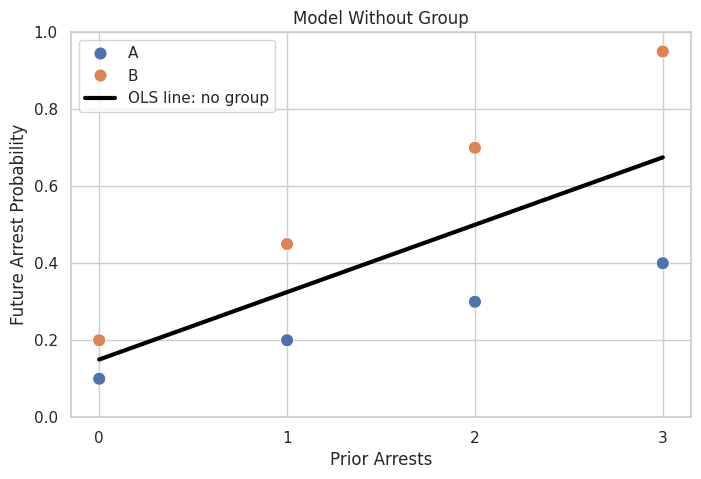

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=cell_rates,
    x='prior_arrests',
    y='future_arrest',
    hue='group',
    s=90
)
plt.plot(
    pred_no_group['prior_arrests'],
    pred_no_group['pred_no_group'],
    color='black',
    linewidth=3,
    label='OLS line: no group'
)
plt.title('Model Without Group')
plt.xlabel('Prior Arrests')
plt.ylabel('Future Arrest Probability')
plt.xticks([0, 1, 2, 3])
plt.ylim(0, 1)
plt.legend();
plt.show();

The dots show the observed arrest rates in the generated data. The black line is the fitted no-group model.

This line is a compromise: it is forced to use the same intercept and slope for everyone.

## 3. Model With Group, But No Interaction

Now add group:

$$
\widehat{future\_arrest} = \hat{b}_0 + \hat{b}_1 prior\_arrests + \hat{b}_2 group\_b
$$

Here, `group_b = 1` for Group B and `group_b = 0` for Group A.

In [6]:
model_group_no_interaction = LinearRegression()
model_group_no_interaction.fit(
    example[['prior_arrests', 'group_b']],
    example['future_arrest']
)

group_no_interaction_coefficients = pd.DataFrame({
    'term': ['intercept', 'prior_arrests', 'group_b'],
    'coefficient': [
        model_group_no_interaction.intercept_,
        model_group_no_interaction.coef_[0],
        model_group_no_interaction.coef_[1]
    ]
})

group_no_interaction_coefficients

LinearRegression()

,term,coefficient
0,intercept,-0.0125
1,prior_arrests,0.1750
2,group_b,0.3250


This model allows different intercepts by group, but it still forces the slope on `prior_arrests` to be the same.

For Group A, `group_b = 0`, so:

$$
\widehat{future\_arrest} = \hat{b}_0 + \hat{b}_1 prior\_arrests
$$

For Group B, `group_b = 1`, so:

$$
\widehat{future\_arrest} = (\hat{b}_0 + \hat{b}_2) + \hat{b}_1 prior\_arrests
$$

The intercept changes. The slope remains `\hat{b}_1` for both groups.

In [7]:
example['pred_group_no_interaction'] = model_group_no_interaction.predict(
    example[['prior_arrests', 'group_b']]
)

pred_group_no_interaction = example[
    ['group', 'prior_arrests', 'pred_group_no_interaction']
].drop_duplicates().sort_values(['group', 'prior_arrests'])

pred_group_no_interaction

,group,prior_arrests,pred_group_no_interaction
0,A,0,-0.0125
20,A,1,0.1625
40,A,2,0.3375
60,A,3,0.5125
80,B,0,0.3125
100,B,1,0.4875
120,B,2,0.6625
140,B,3,0.8375


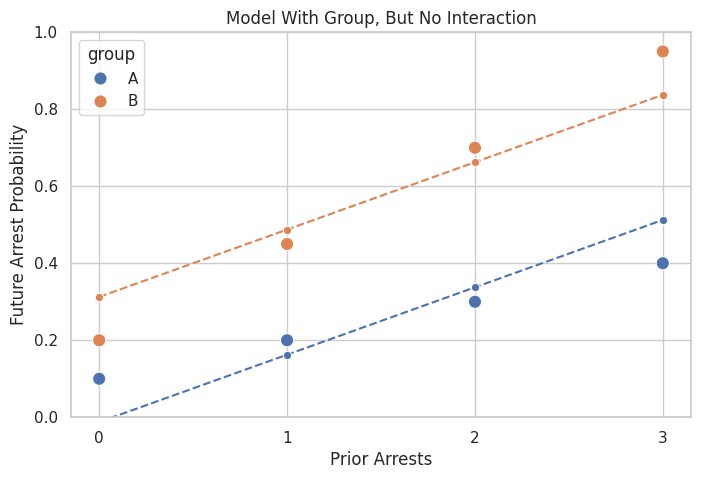

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=cell_rates,
    x='prior_arrests',
    y='future_arrest',
    hue='group',
    s=90
)
sns.lineplot(
    data=pred_group_no_interaction,
    x='prior_arrests',
    y='pred_group_no_interaction',
    hue='group',
    marker='o',
    linestyle='--',
    legend=False
)
plt.title('Model With Group, But No Interaction')
plt.xlabel('Prior Arrests')
plt.ylabel('Future Arrest Probability')
plt.xticks([0, 1, 2, 3])
plt.ylim(0, 1)
plt.legend(title='group');
plt.show();

The fitted lines are parallel. That is the key visual point.

Different intercepts mean different baseline predictions by group. Here, the baseline case is someone with `prior_arrests = 0`, so the model predicts different future-arrest probabilities for Group A and Group B among people with no prior arrests.

Because there is no interaction, each additional prior arrest changes the prediction by the same amount for both groups.

The model can say: “these groups start at different baseline levels.”

It cannot say: “prior arrests matter differently for these groups.”

## 4. Model With Group and an Interaction

Now add the interaction:

$$
\widehat{future\_arrest} = \hat{b}_0 + \hat{b}_1 prior\_arrests + \hat{b}_2 group\_b + \hat{b}_3(prior\_arrests \times group\_b)
$$

The interaction term is `prior_arrests × group_b`.

In [9]:
example['prior_arrests_x_group_b'] = example['prior_arrests'] * example['group_b']

model_group_interaction = LinearRegression()
model_group_interaction.fit(
    example[['prior_arrests', 'group_b', 'prior_arrests_x_group_b']],
    example['future_arrest']
)

group_interaction_coefficients = pd.DataFrame({
    'term': ['intercept', 'prior_arrests', 'group_b', 'prior_arrests_x_group_b'],
    'coefficient': [
        model_group_interaction.intercept_,
        model_group_interaction.coef_[0],
        model_group_interaction.coef_[1],
        model_group_interaction.coef_[2]
    ]
})

group_interaction_coefficients

LinearRegression()

,term,coefficient
0,intercept,0.10
1,prior_arrests,0.10
2,group_b,0.10
3,prior_arrests_x_group_b,0.15


Now the model can estimate both different intercepts and different slopes by group.

For Group A, `group_b = 0`, so the group term and interaction term disappear:

$$
\widehat{future\_arrest} = \hat{b}_0 + \hat{b}_1 prior\_arrests
$$

For Group B, `group_b = 1`, so:

$$
\widehat{future\_arrest} = (\hat{b}_0 + \hat{b}_2) + (\hat{b}_1 + \hat{b}_3)prior\_arrests
$$

So for Group B:

- intercept = `intercept + group_b coefficient`
- slope = `prior_arrests coefficient + interaction coefficient`

In [10]:
example['pred_group_interaction'] = model_group_interaction.predict(
    example[['prior_arrests', 'group_b', 'prior_arrests_x_group_b']]
)

pred_group_interaction = example[
    ['group', 'prior_arrests', 'pred_group_interaction']
].drop_duplicates().sort_values(['group', 'prior_arrests'])

pred_group_interaction

,group,prior_arrests,pred_group_interaction
0,A,0,0.10
20,A,1,0.20
40,A,2,0.30
60,A,3,0.40
80,B,0,0.20
100,B,1,0.45
120,B,2,0.70
140,B,3,0.95


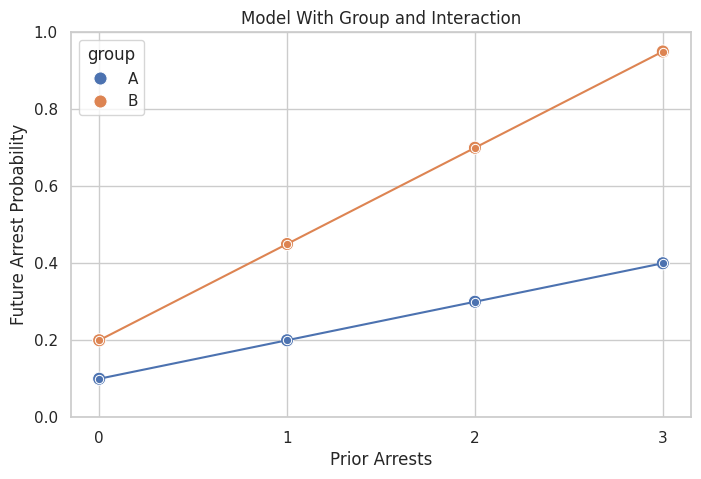

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=cell_rates,
    x='prior_arrests',
    y='future_arrest',
    hue='group',
    s=90
)
sns.lineplot(
    data=pred_group_interaction,
    x='prior_arrests',
    y='pred_group_interaction',
    hue='group',
    marker='o',
    legend=False
)
plt.title('Model With Group and Interaction')
plt.xlabel('Prior Arrests')
plt.ylabel('Future Arrest Probability')
plt.xticks([0, 1, 2, 3])
plt.ylim(0, 1)
plt.legend(title='group');
plt.show();

The lines are no longer parallel. The interaction allows the relationship between prior arrests and future arrest probability to differ by group.

## 5. Compare the Models

First, compare the no-group model to the model with group but no interaction.

The no-group line is plotted in thick black so it does not get hidden by the group-specific lines.

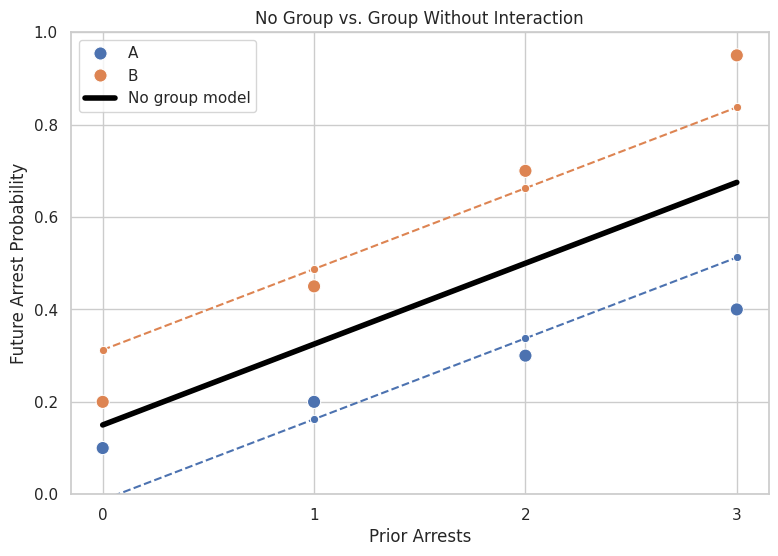

In [12]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=cell_rates,
    x='prior_arrests',
    y='future_arrest',
    hue='group',
    s=90
)

plt.plot(
    pred_no_group['prior_arrests'],
    pred_no_group['pred_no_group'],
    color='black',
    linewidth=4,
    label='No group model'
)

sns.lineplot(
    data=pred_group_no_interaction,
    x='prior_arrests',
    y='pred_group_no_interaction',
    hue='group',
    marker='o',
    linestyle='--',
    legend=False
)

plt.title('No Group vs. Group Without Interaction')
plt.xlabel('Prior Arrests')
plt.ylabel('Future Arrest Probability')
plt.xticks([0, 1, 2, 3])
plt.ylim(0, 1)
plt.legend();
plt.show();

Now compare the model without an interaction to the model with an interaction.

Dashed lines show the model with group but no interaction. Solid lines show the model with group and interaction.

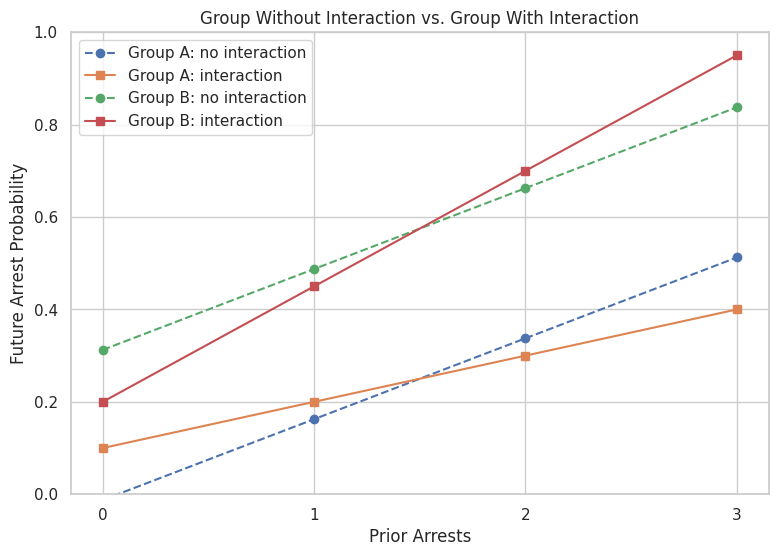

In [13]:
plt.figure(figsize=(9, 6))

for group_name, group_df in pred_group_no_interaction.groupby('group'):
    interaction_group_df = pred_group_interaction[
        pred_group_interaction['group'] == group_name
    ]

    plt.plot(
        group_df['prior_arrests'],
        group_df['pred_group_no_interaction'],
        marker='o',
        linestyle='--',
        label=f'Group {group_name}: no interaction'
    )
    plt.plot(
        interaction_group_df['prior_arrests'],
        interaction_group_df['pred_group_interaction'],
        marker='s',
        linestyle='-',
        label=f'Group {group_name}: interaction'
    )

plt.title('Group Without Interaction vs. Group With Interaction')
plt.xlabel('Prior Arrests')
plt.ylabel('Future Arrest Probability')
plt.xticks([0, 1, 2, 3])
plt.ylim(0, 1)
plt.legend();
plt.show();

## 6. Why This Matters for Fairness

Interactions matter because predictors may not mean the same thing across groups.

Suppose prior arrests are being used as a proxy for prior offending. If policing is more intensive for one group, prior arrests may reflect both offending and surveillance. The same number of prior arrests may therefore carry different information across groups.

A model without an interaction treats prior arrests as having the same relationship with the outcome for every group. A model with an interaction allows that relationship to differ.

That can change calibration, false positive rates, false negative rates, and who gets flagged by the model.

## 7. What Interactions Do Not Solve

Interactions do not automatically make a model fair.

They can help when a predictor has different meaning across groups. They do not fix the deeper problem if the outcome itself is biased.

For example, if the model is trained to predict future arrest, and future arrest is affected by unequal policing, then the model is still learning patterns in future arrest. Adding group or group interactions may help predict future arrest more accurately, but it does not turn future arrest into true offending.